In [1]:
%load_ext autoreload
%autoreload 2

# general
from pathlib import Path
import numpy as np
from tqdm import tqdm
import pandas as pd
import os


# plotting
import seaborn as sns
import matplotlib as mp
import matplotlib.pyplot as plt
import cmcrameri.cm as cm
from helpers import plot_1_panel

mp.rcParams['font.family'] = 'serif'
mp.rcParams['font.serif'] = 'Times New Roman'
mp.rcParams['mathtext.fontset'] = 'stix'   
mp.rcParams['xtick.labelsize'] = 18
mp.rcParams['ytick.labelsize'] = 18
mp.rcParams['axes.titlesize'] = 20
mp.rcParams['axes.labelsize'] = 20
mp.rcParams['legend.title_fontsize'] = 24

# silence divide errors
import warnings
warnings.filterwarnings("ignore")

### Setup

In [2]:
DATASET_NAMES_FORMATTED = {'arxiv_math.LO': 'ArXiv Math.LO', 
                 'arxiv_math.KT': 'ArXiv Math.KT',
                'arxiv_math.GN': 'ArXiv Math.GN', 
                 'cooking-italian': 'Cooking (Italian)', 
                 'kenyan_household_H': 'Kenyan Household', 
                 'FnF_2010-08': 'Friends & Family\n(2010-08)',
                 'FnF_2010-09': 'Friends & Family\n(2010-09)',
                 'FnF_2010-10': 'Friends & Family \n(2010-10)',
                 'FnF_2010-11': 'Friends & Family\n(2010-11)',
                 'cat-edge-algebra-questions': 'Algebra questions',
                 'cat-edge-geometry-questions': 'Geometry questions',
                 'email-eu': 'Email EU',
                 'email-enron': 'Email Enron', 
                 'coauth-cs-CVPR': 'CVPR coauthorship',
                 'coauth-cs-KDD': 'KDD coauthorship',
                 'cora': 'Cora',
                 'flavourcompounds': 'Flavour Compounds',
                 'H_DAWN_0': 'DAWN',
                 'ndc-substances': 'NDC Substances',
                 'ECO-M_PL_015_plants': 'ECO-M-PL-015\nPlants',
                 'marvel': 'Marvel Universe',
                 'senate-bills': 'Senate Bills'  
                 }
DATASETS = sorted(list(DATASET_NAMES_FORMATTED.keys()))

MAXLEVELS = {'ECO-M_PL_015_plants': 30, 
 'FnF_2010-08': 10, 
 'FnF_2010-09': 12, 
 'FnF_2010-10': 14, 
 'FnF_2010-11': 20, 
 'H_DAWN_0': 15, 
 'cat-edge-DAWN': 23,
 'arxiv_math.GN': 8, 
 'arxiv_math.KT': 12, 
 'arxiv_math.LO': 15, 
 'cat-edge-algebra-questions': 30, 
 'cat-edge-geometry-questions': 30, 
 'coauth-cs-CVPR': 25, 'coauth-cs-KDD': 20, 
 'cooking-brazilian': 20, 'cooking-italian': 30, 
 'cora': 26, 
 'email-enron': 20, 
 'email-eu': 30, 'flavourcompounds': 30, 
 'kenyan_household_H': 11, 'marvel': 30, 
 'ndc-substances': 30, 'senate-bills': 30}

print(f"{len(DATASETS)} datasets")


MAIN_DATASETS = ['email-enron', 'flavourcompounds', 'arxiv_math.LO', 'FnF_2010-10'] # 'cooking-italian',  'senate-bills'


22 datasets


In [ ]:
REPO_ROOT = Path().resolve()
DATA_ROOT = REPO_ROOT / "data"
SAVE_ROOT = REPO_ROOT / "output"

print(REPO_ROOT)
print(DATA_ROOT)
print(SAVE_ROOT)

savedata = True
numreps = 100

### For those datasets available on hypergraphx-data, the following can be used. 

In [4]:
import hypergraphx as hgx
for ds in DATASETS:
    try:
        info = hgx.get_remote_dataset_info(ds)
    except Exception as e:
        continue
    print(info)

# H = hgx.load_hypergraph_from_server("pokemon-moves", store=False)
# info

{'name': 'ECO-M_PL_015_plants', 'href': 'datasets/ECO-M_PL_015_plants.html', 'tags': ['Biology', 'Undirected'], 'vertices': 131, 'edges': 477, 'categories': ['Biology', 'Undirected'], 'filename': 'ECO-M_PL_015_plants', 'directory': 'ECO-M_PL_015_plants'}
{'name': 'cat-edge-algebra-questions', 'href': 'datasets/cat-edge-algebra-questions.html', 'tags': ['Undirected', 'Edge attributed', 'Discussion forum'], 'vertices': 423, 'edges': 980, 'categories': ['Undirected', 'Edge attributed', 'Discussion forum'], 'filename': 'cat-edge-algebra-questions', 'directory': 'cat-edge-algebra-questions'}
{'name': 'cat-edge-geometry-questions', 'href': 'datasets/cat-edge-geometry-questions.html', 'tags': ['Undirected', 'Edge attributed', 'Discussion forum'], 'vertices': 580, 'edges': 888, 'categories': ['Undirected', 'Edge attributed', 'Discussion forum'], 'filename': 'cat-edge-geometry-questions', 'directory': 'cat-edge-geometry-questions'}
{'name': 'coauth-cs-CVPR', 'href': 'datasets/coauth-cs-CVPR.htm

## SUPP

### $\checkmark$ Supp - Table 1 - statistics

In [5]:
from hypergraphx.readwrite import load_hypergraph

In [ ]:

DATASET_TYPES = {'arxiv_math.LO': 'Collaboration', 
                 'arxiv_math.KT': 'Collaboration',
                 'arxiv_math.GN': 'Collaboration',
                 'cooking-italian': 'Culinary',
                 'kenyan_household_H': 'Offline social',
                 'FnF_2010-08': 'Offline social',
                 'FnF_2010-09': 'Offline social',   
                 'FnF_2010-10': 'Offline social',
                 'FnF_2010-11': 'Offline social',
                 'cat-edge-algebra-questions': 'Online social',
                 'cat-edge-geometry-questions': 'Online social',
                 'email-eu': 'Online social',
                 'email-enron': 'Online social',
                 'coauth-cs-CVPR': 'Collaboration',
                 'coauth-cs-KDD': 'Collaboration',   
                 'cora': 'Collaboration',
                 'flavourcompounds': 'Culinary',
                 'H_DAWN_0': 'Pharmacological',
                 'ndc-substances': 'Pharmacological',
                 'ECO-M_PL_015_plants': 'Ecological',
                 'marvel': 'Literary',
                 'senate-bills': 'Political'}

# generates for a single latex row
for ds in DATASETS:
    
    fname_Htrue = DATA_ROOT / f"{ds}.json"
    H = load_hypergraph(str(fname_Htrue))
    _N = H.num_nodes()
    _E = H.num_edges()
    _M = H.max_size()
    _T = DATASET_TYPES[ds]

    f = chr(92) + "fontsize{6}{7}" + chr(92) + "selectfont{" + DATASET_NAMES_FORMATTED[ds] + "}"
    print(f"{f} & {_T} & {_N} & {_E} & {_M} {chr(92)}{chr(92)}")




\fontsize{6}{7}\selectfont{ECO-M-PL-015
Plants} & Ecological & 131 & 477 & 104 \\
\fontsize{6}{7}\selectfont{Friends & Family
(2010-08)} & Offline social & 44 & 436 & 9 \\
\fontsize{6}{7}\selectfont{Friends & Family
(2010-09)} & Offline social & 58 & 1155 & 11 \\
\fontsize{6}{7}\selectfont{Friends & Family 
(2010-10)} & Offline social & 128 & 4832 & 13 \\
\fontsize{6}{7}\selectfont{Friends & Family
(2010-11)} & Offline social & 126 & 6094 & 20 \\
\fontsize{6}{7}\selectfont{DAWN} & Pharmacological & 898 & 4816 & 13 \\
\fontsize{6}{7}\selectfont{ArXiv Math.GN} & Collaboration & 4718 & 3791 & 33 \\
\fontsize{6}{7}\selectfont{ArXiv Math.KT} & Collaboration & 3954 & 4050 & 10 \\
\fontsize{6}{7}\selectfont{ArXiv Math.LO} & Collaboration & 7654 & 8870 & 20 \\
\fontsize{6}{7}\selectfont{Algebra questions} & Online social & 423 & 980 & 107 \\
\fontsize{6}{7}\selectfont{Geometry questions} & Online social & 580 & 888 & 230 \\
\fontsize{6}{7}\selectfont{CVPR coauthorship} & Collaboration & 18835 

### $\checkmark$ Supp - Fig. S1 - edge-size distributions

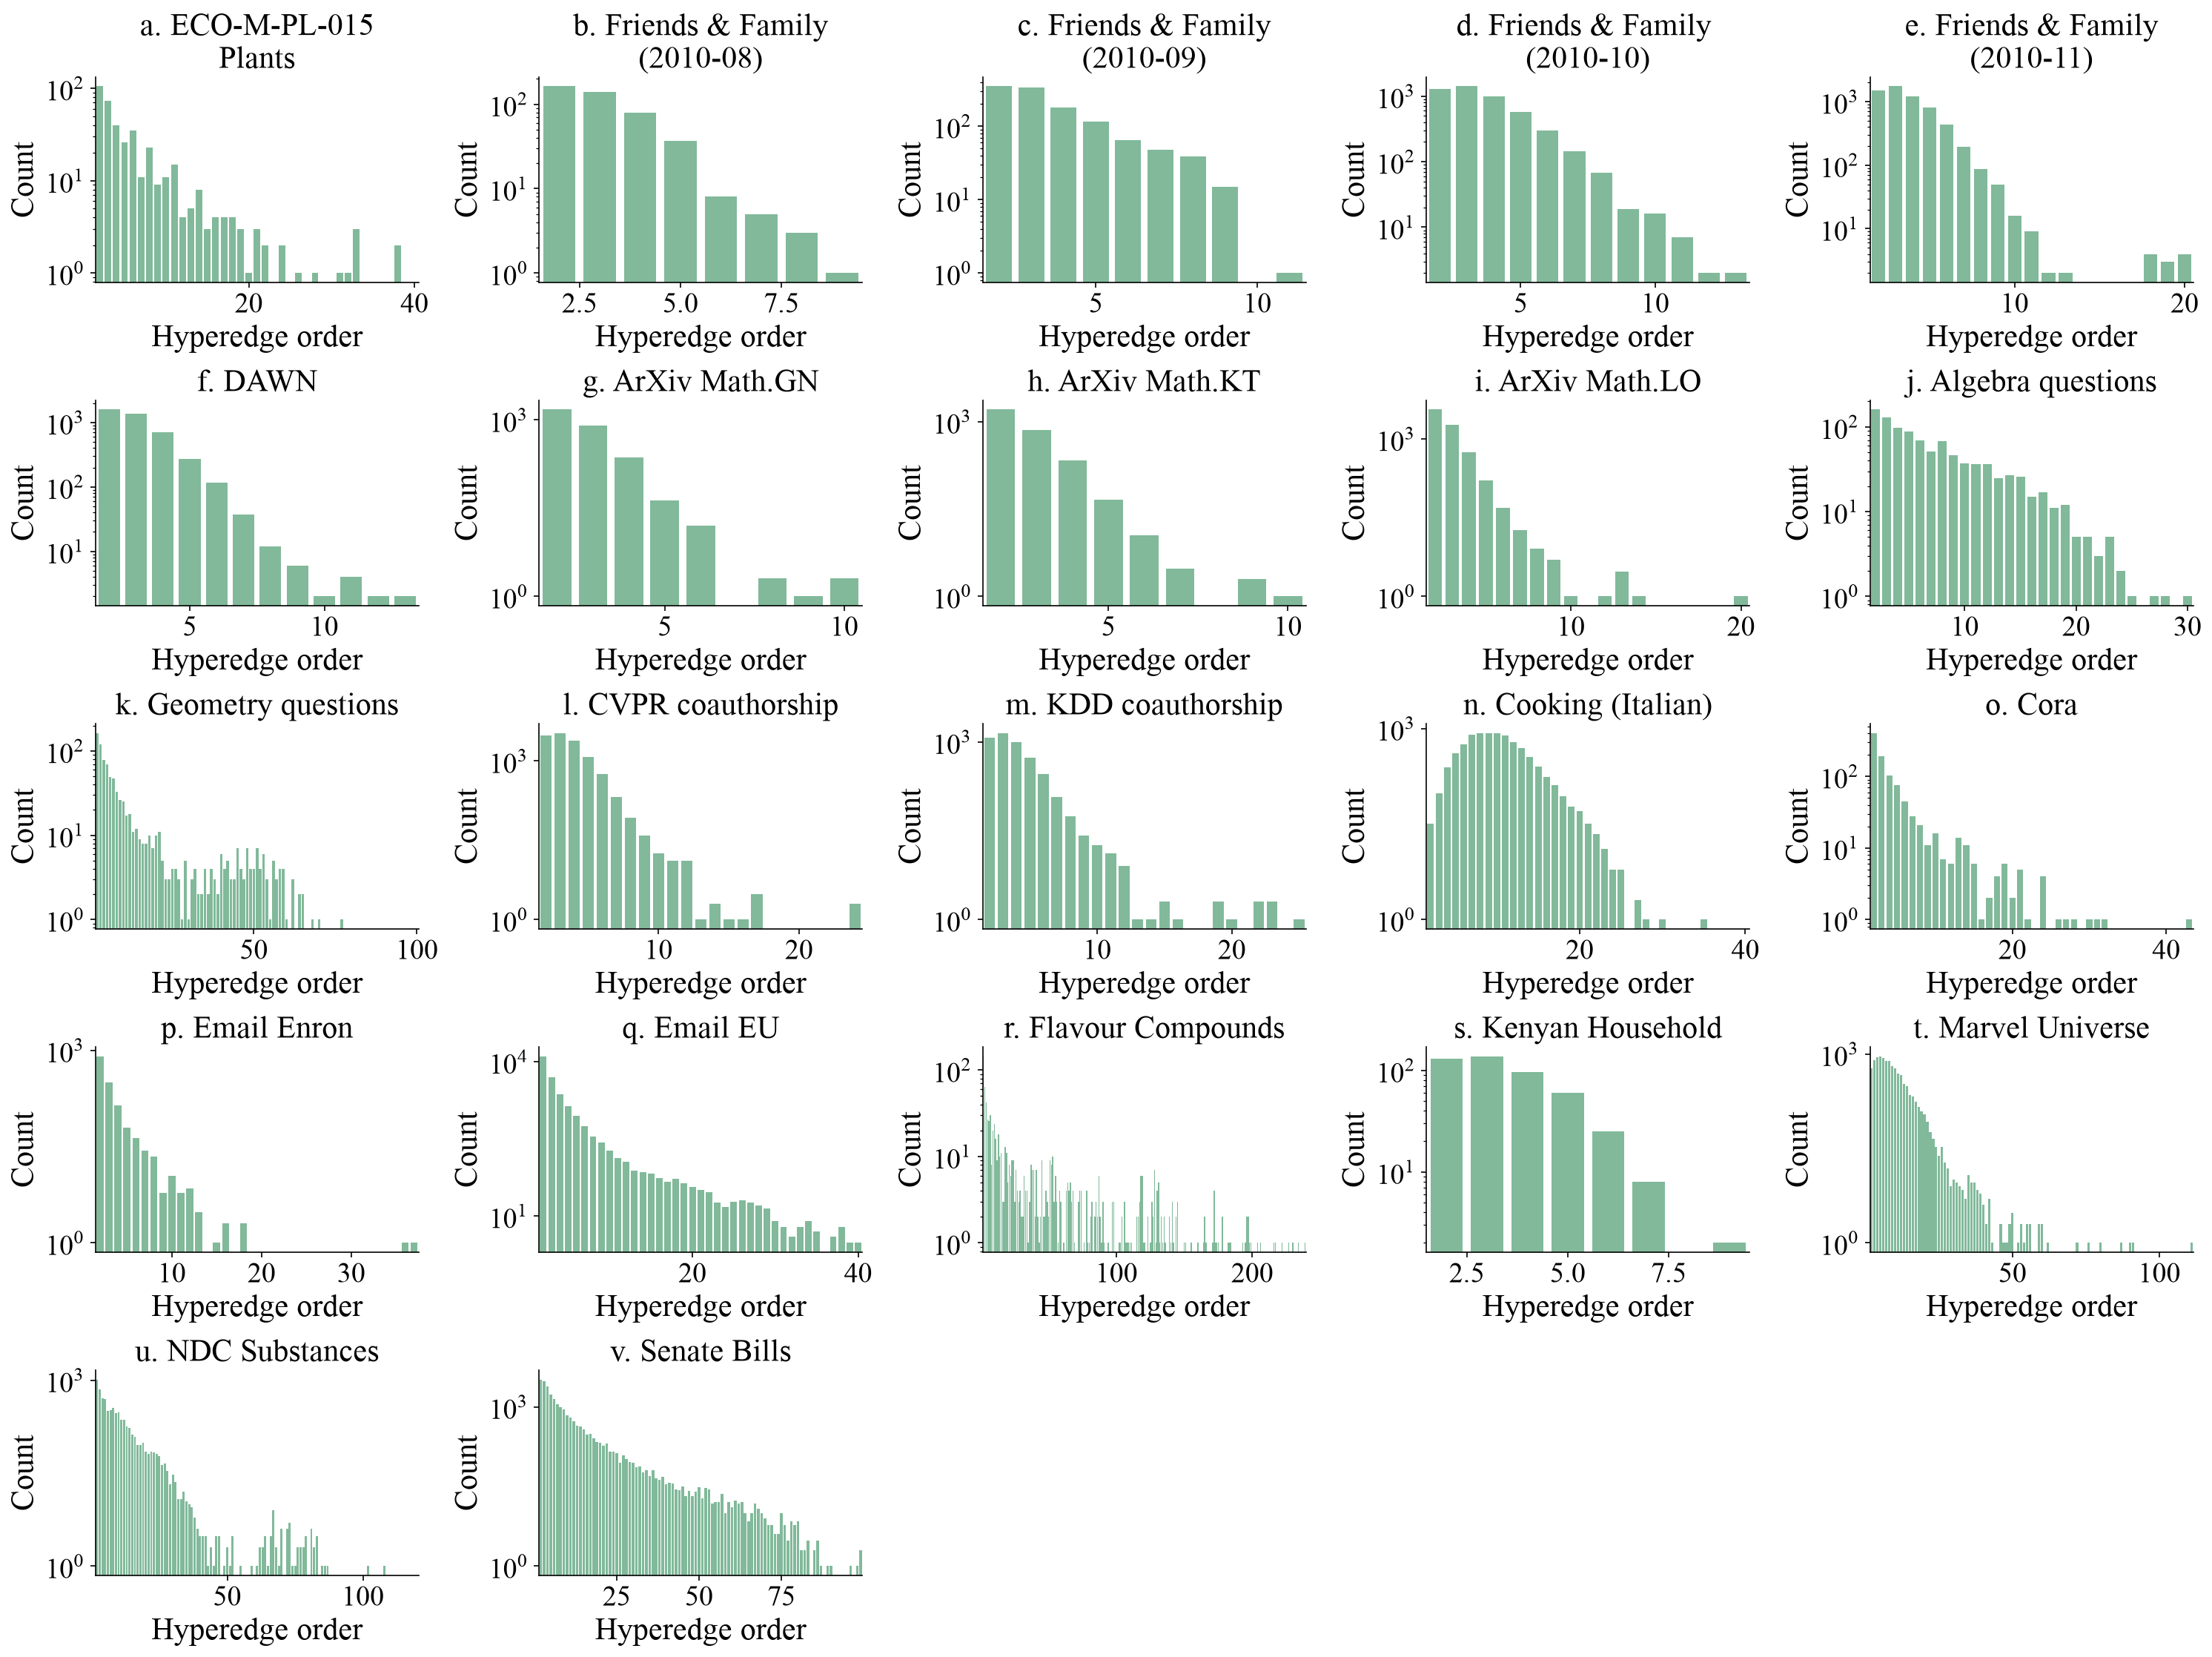

In [ ]:

nrows = 5
ncols = len(DATASETS) // nrows + (1 if len(DATASETS) % nrows > 0 else 0)
fig, axes = plt.subplots(nrows, ncols, figsize=(4*ncols, 3*nrows), 
                         tight_layout=True, 
                         dpi=150)
axes = axes.flatten()
savedata = True

CUTOFF = {'ECO-M_PL_015_plants': 40,
 'FnF_2010-08': 9,
 'FnF_2010-09': 11,
 'FnF_2010-10': 13,
 'FnF_2010-11': 20,
 'H_DAWN_0': 13,
 'arxiv_math.GM': 11,
 'arxiv_math.GN': 10,
 'arxiv_math.KT': 10,
 'arxiv_math.LO': 20,
 'cat-edge-algebra-questions': 30,
 'cat-edge-geometry-questions': 100,
 'coauth-cs-CVPR': 24,
 'coauth-cs-KDD': 25,
 'cooking-brazilian': 36,
 'cooking-italian': 40,
 'cora': 43,
 'email-enron': 37,
 'email-eu': 40,
 'flavourcompounds': 239,
 'kenyan_household_H': 9,
 'marvel': 111,
 'ndc-substances': 120,
 'senate-bills': 99}
 
# i = letter index offset
for i, (ds, ax) in enumerate(zip(DATASETS, axes)):

    fname_Htrue = DATA_ROOT / f"{ds}.json"
    H = load_hypergraph(str(fname_Htrue))
    data = pd.Series(H.get_sizes()).value_counts().sort_index()
    if 1 in data.index:
        data = data.drop(1)  # Drop hyperedges of size 1 if present

    ax.bar(data.index, data.values, 
            color='seagreen', 
            alpha=0.6,
            linewidth=1.2,
            log=True)

    ax.set_title(chr(97+i) + '. ' + DATASET_NAMES_FORMATTED[ds], fontsize=20)
    ax.set_xlabel('Hyperedge order')
    ax.set_ylabel('Count')
    ax.set_yscale('log')


    ax.set_xlim(left=1.5, right=CUTOFF[ds]+0.5)      

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    
for ax in axes[len(DATASETS):]:
    ax.axis('off')    

if savedata:
    fname_out = SAVE_ROOT / "figures" / "Supp_fig1.png"
    if not fname_out.parent.exists(): fname_out.parent.mkdir(parents=True)
    fig.savefig(fname_out, bbox_inches='tight', dpi=300)
    

### $\checkmark$ Supp - Fig. S2 - Average z-scores

In [8]:
mp.rcParams['font.family'] = 'serif'
mp.rcParams['xtick.labelsize'] = 14
mp.rcParams['ytick.labelsize'] = 14
mp.rcParams['axes.titlesize'] = 16
mp.rcParams['axes.labelsize'] = 16
mp.rcParams['legend.title_fontsize'] = 16
mp.rcParams['mathtext.fontset'] = 'stix'  


In [9]:
def calculate_zscores_for_datasets(DATASETS, SAVE_ROOT, numreps=100):

    zscores_all_datasets = {}
    zscores_fingerprints = {}

    for ds in tqdm(DATASETS):
        I_true = np.nan_to_num(np.load(SAVE_ROOT / "empirical" / ds / f"MF1_HOCM{numreps}data.npz")['I_true'], nan=0.0)
        I_inter_for_RH = np.load(SAVE_ROOT / "empirical" / ds / f"MF1_HOCM{numreps}data.npz")['I_HOCM']
        I_HOCM_mean = np.nan_to_num(np.nanmean(I_inter_for_RH, axis=0), nan=0.0)
        I_HOCM_std = np.nan_to_num(np.nanstd(I_inter_for_RH, axis=0), nan=0.0)

        a = (I_true)
        b = (I_HOCM_mean)
        c = (I_HOCM_std)


        z = (a-b)/c
        z[np.isinf(abs(z))] = np.nan
        zscores_all_datasets[ds] = [np.nanmean(z), np.nanstd(z)]
        zscores_fingerprints[ds] = z
        
    return zscores_all_datasets, zscores_fingerprints


In [ ]:
def plot_Fig2_zscores_SUPP(zscores_all_datasets, DATASET_NAMES_FORMATTED):

    df_zscores_all_datasets = pd.DataFrame.from_dict(
        zscores_all_datasets, 
        orient='index', 
        columns=['Mean', 'Std']).sort_values(
            'Std', ascending=False).sort_values(
                'Mean', ascending=False)
    # scatter plot with error bars
    fig, ax = plt.subplots(figsize=(len(zscores_all_datasets)/2, 4), tight_layout=True, dpi=200)
    x = range(len(df_zscores_all_datasets))
    for _x, _y, _err in zip(x, df_zscores_all_datasets['Mean'], df_zscores_all_datasets['Std']):
        c = 'navy' if _y > 2 else 'darkgreen' if _y >= 0 else 'darkorange' if _y < 0 else 'k'
        ecolor = 'cornflowerblue' if _y > 2 else 'mediumseagreen' if _y >= 0 else 'peachpuff' if _y < 0 else 'k'
        # make dot darker and error bar lighter
        ax.errorbar(x=_x, y=_y, yerr=_err, capsize=5, fmt='o', c=c, ecolor=ecolor)
    ax.axhline(y=1, color='lightgrey', linestyle='--')
    ax.axhline(y=2, color='lightgrey', linestyle='--')
    # add legend with dataset names
    # Create legend labels like "1 - long name"
    legend_labels = [f"{i+1} - {name}" for i, name in zip(x, [DATASET_NAMES_FORMATTED[ds] for ds in df_zscores_all_datasets.index])]
    cols = ['navy' if  df_zscores_all_datasets.loc[ds, 'Mean'] > 2 else 'darkgreen' if df_zscores_all_datasets.loc[ds, 'Mean'] >= 0 else 'darkorange' if df_zscores_all_datasets.loc[ds, 'Mean'] < 0 else 'k' for ds in df_zscores_all_datasets.index]

    # Dummy handles for legend
    for label, c in zip(legend_labels, cols):
        _lbl = label.split(" - ")[1]
        plt.plot([], [], label=label, c=c)

    # layout of legend = tight
    fig.legend( 
            bbox_to_anchor=(0.5, -0.35), 
            frameon=False,
                loc='lower center',
            ncols=4, 
            )

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    ax.text(0.8, 1.2, rf'$z=1$', fontsize=14, color='k', va='center', ha='right', alpha=0.7)
    ax.text(0.8, 2.5, rf'$z=2$', fontsize=14, color='k', va='center', ha='right', alpha=0.7)


    plt.xlabel('Dataset')
    plt.ylabel(r'$\langle z \rangle \pm \sigma_z$')
    plt.xticks(x, range(1, len(df_zscores_all_datasets)+1))
    ax.set_yscale('log')
    ax.set_ylim(bottom=0.1)

    return fig

In [ ]:
zscores_all_datasets, zscores_fingerprints = calculate_zscores_for_datasets(DATASETS, 
                                                      SAVE_ROOT=SAVE_ROOT,
                                                      numreps=numreps)

if savedata:
    fname_out = REPO_ROOT / 'data' / f"SF2_zscores.npz"
    if not fname_out.parent.exists(): fname_out.parent.mkdir(parents=True)
    np.savez(fname_out, ZSCORE_FINGERPRINTS=zscores_fingerprints, ZSCORES_MEANSTD=zscores_all_datasets)        # , ZSCORE_FINGERPRINTS=_ZSCORE_FINGERPRINTS
    # print(f"Saved z-scores to {fname_out}")

  0%|          | 0/22 [00:00<?, ?it/s]

100%|██████████| 22/22 [00:00<00:00, 657.11it/s]


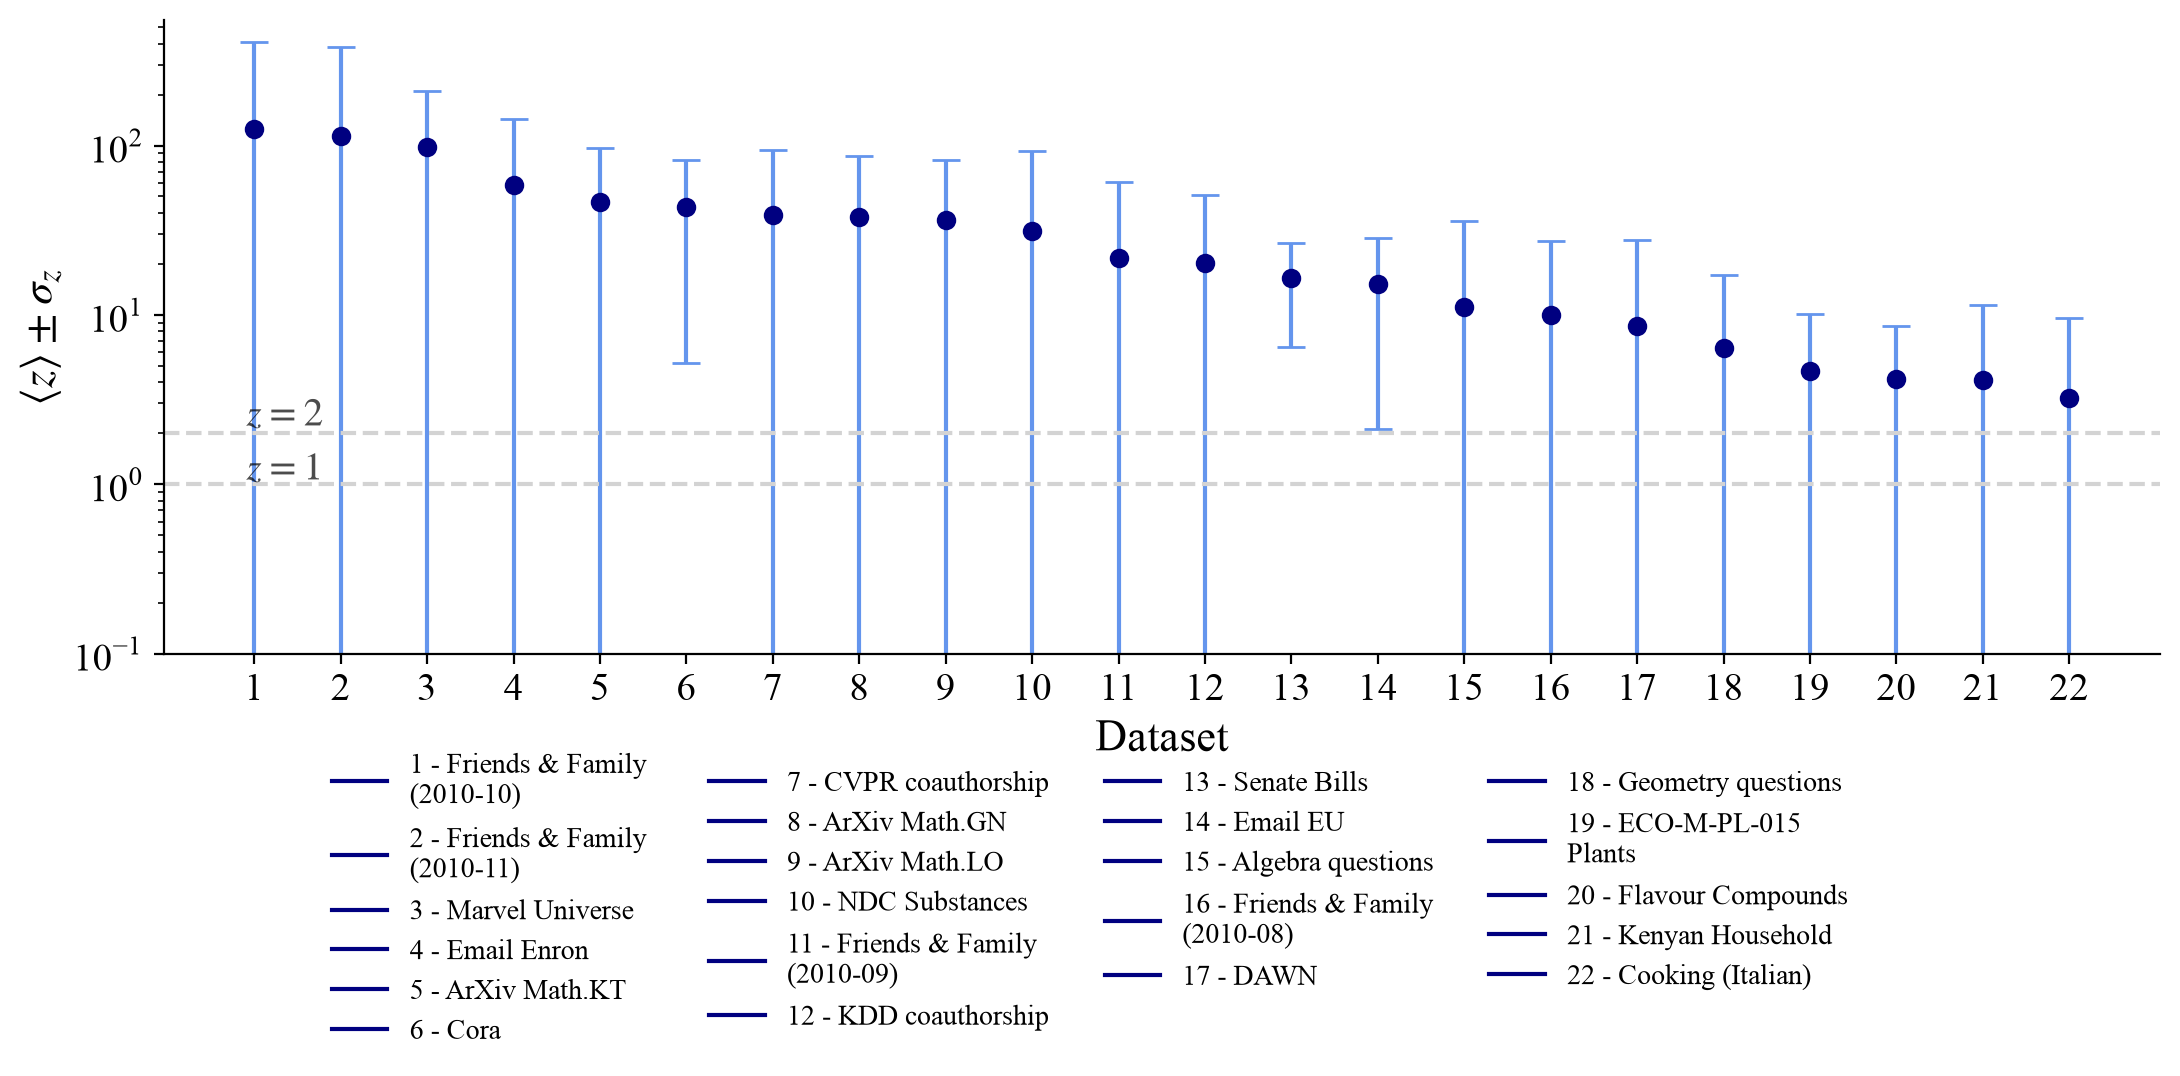

In [27]:
fig = plot_Fig2_zscores_SUPP(zscores_all_datasets, DATASET_NAMES_FORMATTED)

if savedata:
    ftype = "pdf"
    fname_out = SAVE_ROOT / "figures" / f"Supp_fig2.{ftype}"
    if not fname_out.parent.exists(): fname_out.parent.mkdir(parents=True)
    fig.savefig(fname_out, bbox_inches='tight', dpi=300)

### $\checkmark$ Supp - Fig. S3 - Comparison fingerprints: True vs. Randomised (HOCM)

In [13]:
from helpers import plot_zscore

In [ ]:

def plot_Fig3_SUPP(DATASETS, nrows=6, savedata=True, numreps=100):

    fname_zscore = REPO_ROOT/ 'data' / f"SF2_zscores.npz"
    ZSCORES = np.load(fname_zscore, allow_pickle=True)['ZSCORE_FINGERPRINTS'].item()


    ncols = len(DATASETS) // nrows + (1 if len(DATASETS) % nrows > 0 else 0)
    
    print(f"Plotting {len(DATASETS)} datasets in {nrows} rows and {ncols} columns")

    imwidth = 4.5
    fig = plt.figure(figsize=(imwidth*ncols*2, imwidth*nrows), 
                    constrained_layout=True)
    subfigs = fig.subfigures(nrows, ncols, 
                            height_ratios=[1 for _ in range(nrows)],
                            hspace=.1, wspace=.04)
    subfigs = subfigs.flatten()

    figctr = 0
    for i, ds in tqdm(enumerate(DATASETS), total=len(DATASETS)):               
        
        
        # Load data
        I_true = np.nan_to_num(np.load(SAVE_ROOT / "empirical" / ds / f"MF1_HOCM{numreps}data.npz")['I_true'], nan=0.0)
        I_inter_for_RH = np.load(SAVE_ROOT / "empirical" / ds / f"MF1_HOCM{numreps}data.npz")['I_HOCM']
        I_HOCM_mean = np.nan_to_num(np.nanmean(I_inter_for_RH, axis=0), nan=0.0)

        fig1 = subfigs[figctr]
        figctr += 1
        axes1 = fig1.subplots(1, 2, 
                            width_ratios=[1, 1], gridspec_kw={'wspace': 0.001})

        # Panel 1. True vs Randomised
        startpos = 0
        maxlevel_to_plot = min(MAXLEVELS[ds], I_true.shape[0]) - 3     # remove two since first entry will be for pairs
            
        matrix = np.nan_to_num(I_true[startpos:, startpos:].T) + np.nan_to_num(I_HOCM_mean[startpos:, startpos:])

        plot_every_nth = 2
        plot_1_panel(dataArr=matrix[:maxlevel_to_plot, :maxlevel_to_plot], 
                    xticklabels=range(startpos+2, len(matrix)+2), 
                    yticklabels=range(startpos+2, len(matrix)+2), cmap=cm.devon_r, 
                    xlabel="Randomised\n(HOCM)", ylabel="Data", 
                    vmin=np.nanmin(matrix[np.nonzero(matrix)]), vmax=np.nanmax(matrix[np.nonzero(matrix)]),
                    log_option=True,
                    step = plot_every_nth,
                    ax=axes1[0],
                    title="")
        axes1[0].set_aspect('equal')
        axes1[0].plot(np.linspace(-0.5, maxlevel_to_plot-0.5, num=10), 
                        np.linspace(-0.5, maxlevel_to_plot-0.5, num=10), 
                        color='darkorange', linestyle='--', alpha=0.9, linewidth=4.0);
            
        # Panel 2. Z-score
        if ds not in ZSCORES:
            print(f"Skipping {ds} since no z-score data")
            continue
        zscore_I = ZSCORES[ds].T
        zscore_I = np.tril(zscore_I, k=-1)
        plot_zscore(ax=axes1[1], fig=fig1, zscore_I=zscore_I, 
                    maxlevel=MAXLEVELS[ds], 
                    cmap = cm.bam,
                    cmap_onesided='Greens'
                    )

        fig1.suptitle(chr(97+i) + '. ' + DATASET_NAMES_FORMATTED[ds], fontsize=28)
        
        if savedata:
            bbox = fig1.bbox
            bbox_inches = bbox.transformed(fig.dpi_scale_trans.inverted())
            fname_out = SAVE_ROOT / "empirical" / ds / f"suppF3_{numreps}.png"
            if not fname_out.parent.exists(): fname_out.parent.mkdir(parents=True)
            fig.savefig(fname_out, 
                        bbox_inches=bbox_inches, dpi=300)


    return fig

Plotting 4 datasets in 1 rows and 4 columns


100%|██████████| 4/4 [00:00<00:00, 42.12it/s]


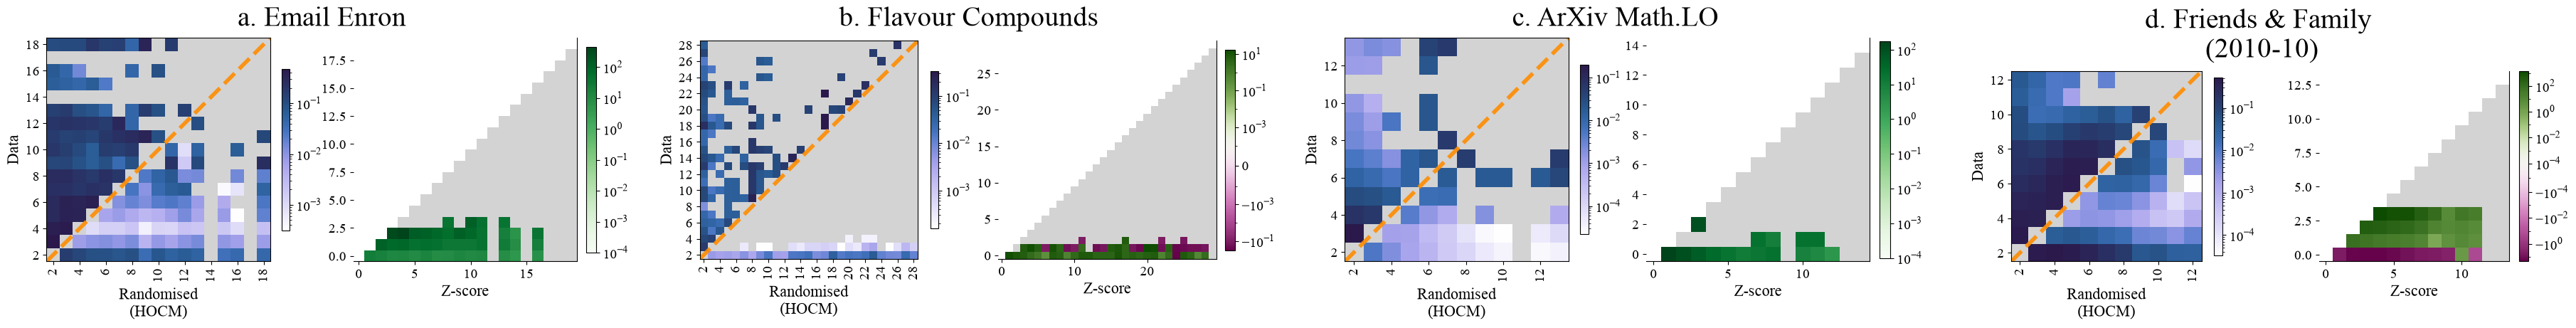

In [15]:
fig = plot_Fig3_SUPP(DATASETS=MAIN_DATASETS, nrows=1, savedata=False)

if savedata:
    fname_out = SAVE_ROOT / 'figures' / f"SUPP_Fig3.png"
    if not fname_out.parent.exists(): fname_out.parent.mkdir(parents=True)
    fig.savefig(fname_out, bbox_inches='tight', dpi=300)
    

### $\checkmark$ Supp - Fig.S4 - Matching nestedness

In [16]:
from helpers import plot_diff_overall_with_crossover

In [17]:
def plot_FigS4_SUPP(DATASETS, nrows=6, 
                   SAVE_ROOT=SAVE_ROOT, 
                   ):

    startpos = 0

    if nrows > 1:
            ncols = len(DATASETS) // nrows + 1 if len(DATASETS) % nrows > 0 else 0
    else: 
            ncols = len(DATASETS)

    fig = plt.figure(figsize=(4.5*ncols, 3.5*nrows), 
            constrained_layout=True)
    
    subfigs = fig.subfigures(nrows, ncols, 
    height_ratios=[1 for _ in range(nrows)],
    hspace=.1, wspace=.1)
    subfigs = subfigs.flatten()

    figctr = 0
    for i, ds in tqdm(enumerate(DATASETS), total=len(DATASETS)):
            
            fig1 = subfigs[figctr]
            figctr += 1
            
            fig1.suptitle(f"{chr(97 + i)}. {DATASET_NAMES_FORMATTED[ds]}", fontsize=24);
            if not (SAVE_ROOT / "empirical" / ds / f"HOGEOM_idx0" / f"{ds}_I_panel.png").exists():
                    print(f"Skipping {ds} since not finished yet")
                    continue        


            axes1 = fig1.subplots(1, 1)
            axes1 = [axes1]
            ROOT_FOR_CROSSOVER = SAVE_ROOT / "empirical" / ds / f"HOGEOM_idx0"
            
            # SECOND PANEL PLOT
            _ax = axes1[0]
            _, _ax, _, DIFFS = plot_diff_overall_with_crossover(ROOT_FOR_CROSSOVER, ds, ax=_ax);
            if ds == 'cooking-italian':
                    _ax.set_xlim(right=2.0)
                    _ax.set_ylim(top=0.1)
                    
            _ax.set_xticklabels(_ax.get_xticks(), fontsize=18)
            _ax.set_yticklabels(np.round(_ax.get_yticks(), decimals=2), fontsize=18)
                    
    return fig
        

100%|██████████| 4/4 [00:00<00:00, 61.45it/s]


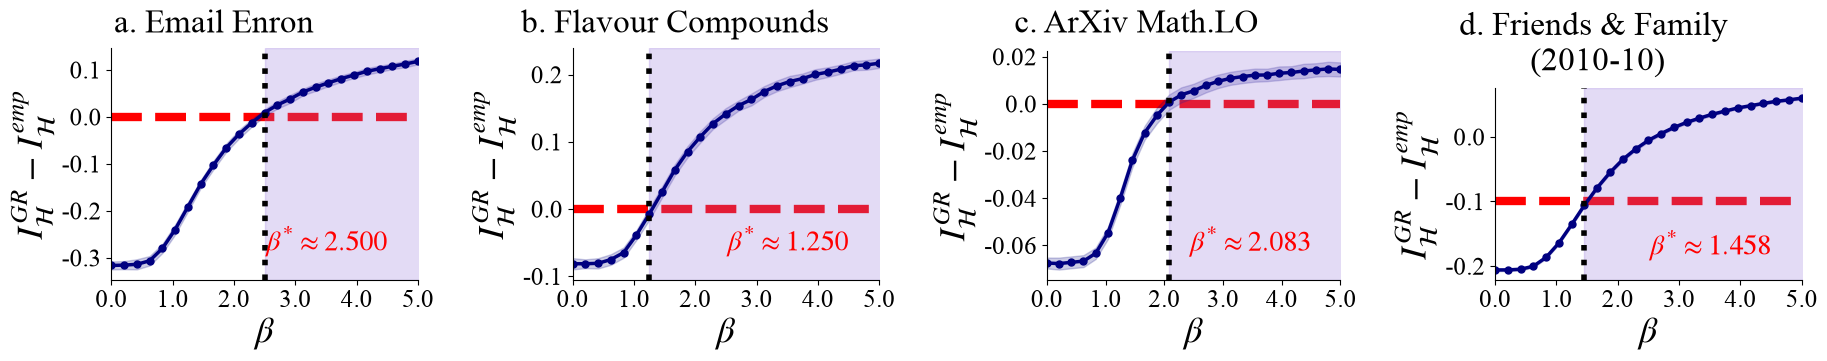

In [18]:
fig = plot_FigS4_SUPP(DATASETS=MAIN_DATASETS, 
               nrows=1)


if savedata:
    fname_out = SAVE_ROOT / "figures" / f"Supp_Fig4.pdf"
    if not fname_out.parent.exists(): fname_out.parent.mkdir(parents=True)
    fig.savefig(fname_out, bbox_inches='tight', dpi=300)
    


### $\checkmark$ Supp - Fig.S5 - Beta table as it evolves

In [19]:
from helpers import bipartite_to_hypergraph, calc_fingerprint_nestedness, reshape_array
import re

In [ ]:
def plot_fingerprints_across_different_beta_values(true_I, realis_directory, ds, 
                                                   beta_vals_to_plot=None,
                                                   imwidth=4, nreps=100, nrows=1, maxlevel=None, subfigure=None):
    startpos = 0
    
    assert realis_directory.is_dir(), f"The directory {realis_directory} does not exist. Please check the path."

    fnames = sorted(os.listdir(realis_directory))
    fnames = [el for el in fnames if f"r_{nreps-1}_"  in el]
    
    if beta_vals_to_plot is not None:
        fnames = [el for el in fnames if any(f"beta_{b:.3f}" in el for b in beta_vals_to_plot)]
        
    fnames.sort(
        key=lambda fname: float(
            re.search(r"(?<=beta_)\d+(?:\.\d+)?(?=_r_)", fname).group()
        )
    )
    
    if subfigure is None:
        ncols = len(fnames) // nrows
        fig, axes = plt.subplots(nrows, ncols, figsize=(imwidth*ncols, imwidth*nrows), 
                                tight_layout=True)
    else:
        fig = subfigure
        ncols = len(fnames) // nrows
        axes = fig.subplots(nrows, ncols)

    if nrows > 1:
        fig.subplots_adjust(hspace=0.3, wspace=0.3)
    
    axes = axes.flatten()

    betavals = []
    for i, (ax, fname) in enumerate(zip(axes, fnames)):
        
        _beta = float(re.search(r"(?<=beta_)\d+(?:\.\d+)?(?=_r_)", fname).group())
        edges = pd.read_csv(realis_directory / fname, sep=' ', dtype=int, header=None).values.tolist()
        H = bipartite_to_hypergraph(edges)
        I_realisation = calc_fingerprint_nestedness(H, max_level=MAXLEVELS[ds]+2)
        I_realisation = np.nan_to_num(I_realisation, nan=0.0)
        I_realisation = reshape_array(I_realisation, (MAXLEVELS[ds]-1, MAXLEVELS[ds]-1), pad_value=0)
        true_I = reshape_array(true_I, (MAXLEVELS[ds]-1, MAXLEVELS[ds]-1), pad_value=0)
        true_I = np.nan_to_num(true_I, nan=0.0)
        I_realisation = np.nan_to_num(I_realisation, nan=0.0)

        matrix = np.nan_to_num(true_I[startpos:, startpos:].T) + np.nan_to_num(I_realisation[startpos:, startpos:])
        matrix = matrix[:maxlevel, :maxlevel] if maxlevel is not None else matrix
        _vmin = np.nanmin(true_I[np.nonzero(true_I)])
        _vmax = np.nanmax(true_I[np.nonzero(true_I)])
        
        plot_every_nth = 1 if matrix.shape[0] <= 10 else 2
        plot_1_panel(dataArr=matrix, 
                xticklabels=range(startpos+2, len(matrix)+2), 
                yticklabels=range(startpos+2, len(matrix)+2), cmap=cm.devon_r, 
                xlabel=rf"GR (HO-$\mathbb{{S}}^1$)",
                ylabel="True" if i == 0 else "", 
                vmin=_vmin, vmax=_vmax,
                log_option=True,
                step = plot_every_nth,
                ax=ax,
                title=rf"{DATASET_NAMES_FORMATTED[ds]}")
        
        ax.plot(np.linspace(-0.5, len(matrix)-0.5, num=10), 
                        np.linspace(-0.5, len(matrix)-0.5, num=10), 
                        color='darkorange', linestyle='--', alpha=0.9, linewidth=4.0);
        
        ax.set_aspect('equal')
        ax.set_title(rf"$\beta={_beta}$", fontsize=30);
        betavals.append(_beta)
        ax.set_xlabel(rf"GR (HO-$\mathbb{{S}}^1$)", fontsize=30)
        # ax.set_ylabel("True" if i == 0 else "", fontsize=20)
        
        I_realisation = None
        edges = None
        

    
    return fig, axes, betavals
    

In [ ]:
def plot_FigS5_SUPP_ALL(DATASETS, MAXLEVELS, DATASET_NAMES, SAVE_ROOT, NREPS, 
                        NROWS,
                        imwidth=5, 
                        savedata=True, 
                        beta_labels=True, 
                        beta_vals_to_plot=None
                        ):
    nrows = len(DATASETS)
    ncols = 1
    if beta_vals_to_plot is not None:
        figure = plt.figure(figsize=(imwidth*len(beta_vals_to_plot), imwidth*nrows), constrained_layout=True)
    else:
        figure = plt.figure(figsize=(imwidth*10, imwidth*nrows), constrained_layout=True)
    subfigs = figure.subfigures(nrows, ncols, height_ratios=[1 for _ in range(nrows)], hspace=.1, wspace=.04)
    if nrows == 1:
        subfigs = [subfigs]
    else:
        subfigs = subfigs.flatten()
    
    for ctr, (ds, _subfig) in enumerate(zip(DATASETS, subfigs)):
        print(f" % {ctr}. {ds.upper()} ")
        fname_hocm = SAVE_ROOT / "empirical" / ds / f"MF1_HOCM100data.npz"
        HOCM_data = np.load(fname_hocm)
        true_I = HOCM_data['I_true'][:MAXLEVELS[ds], :MAXLEVELS[ds]]
        _subfig, axes, _ = plot_fingerprints_across_different_beta_values(true_I=true_I,
                                                    realis_directory=SAVE_ROOT / "empirical" / ds / "HOGeom_idx0" / "realisations",
                                                        imwidth=imwidth, ds=ds, nrows=NROWS[ds], 
                                                        nreps=NREPS[ds],
                                                        maxlevel=MAXLEVELS[ds], 
                                                        beta_vals_to_plot=beta_vals_to_plot,
                                                        subfigure=_subfig);
        if ctr != 0 or not beta_labels:
            for ax in axes:
                ax.set_title("")
        
        axes[0].set_ylabel(f"{DATASET_NAMES[ds]} \nTrue", fontsize=30)
        if savedata:
            # saving the individual panels to the correct dataset folder
            fname_out = SAVE_ROOT / "empirical" / ds / f"suppF5_{ds}.pdf"
            if not fname_out.parent.exists(): fname_out.parent.mkdir(parents=True)
            bbox = _subfig.bbox
            bbox_inches = bbox.transformed(figure.dpi_scale_trans.inverted())
            figure.savefig(fname_out, bbox_inches=bbox_inches, dpi=300)
            print(f"Saved figure for {ds} to {fname_out}")
            
    return figure

nrows=4, ncols=1
 % 0. EMAIL-ENRON 
 % 1. FLAVOURCOMPOUNDS 
 % 2. ARXIV_MATH.LO 
 % 3. FNF_2010-10 


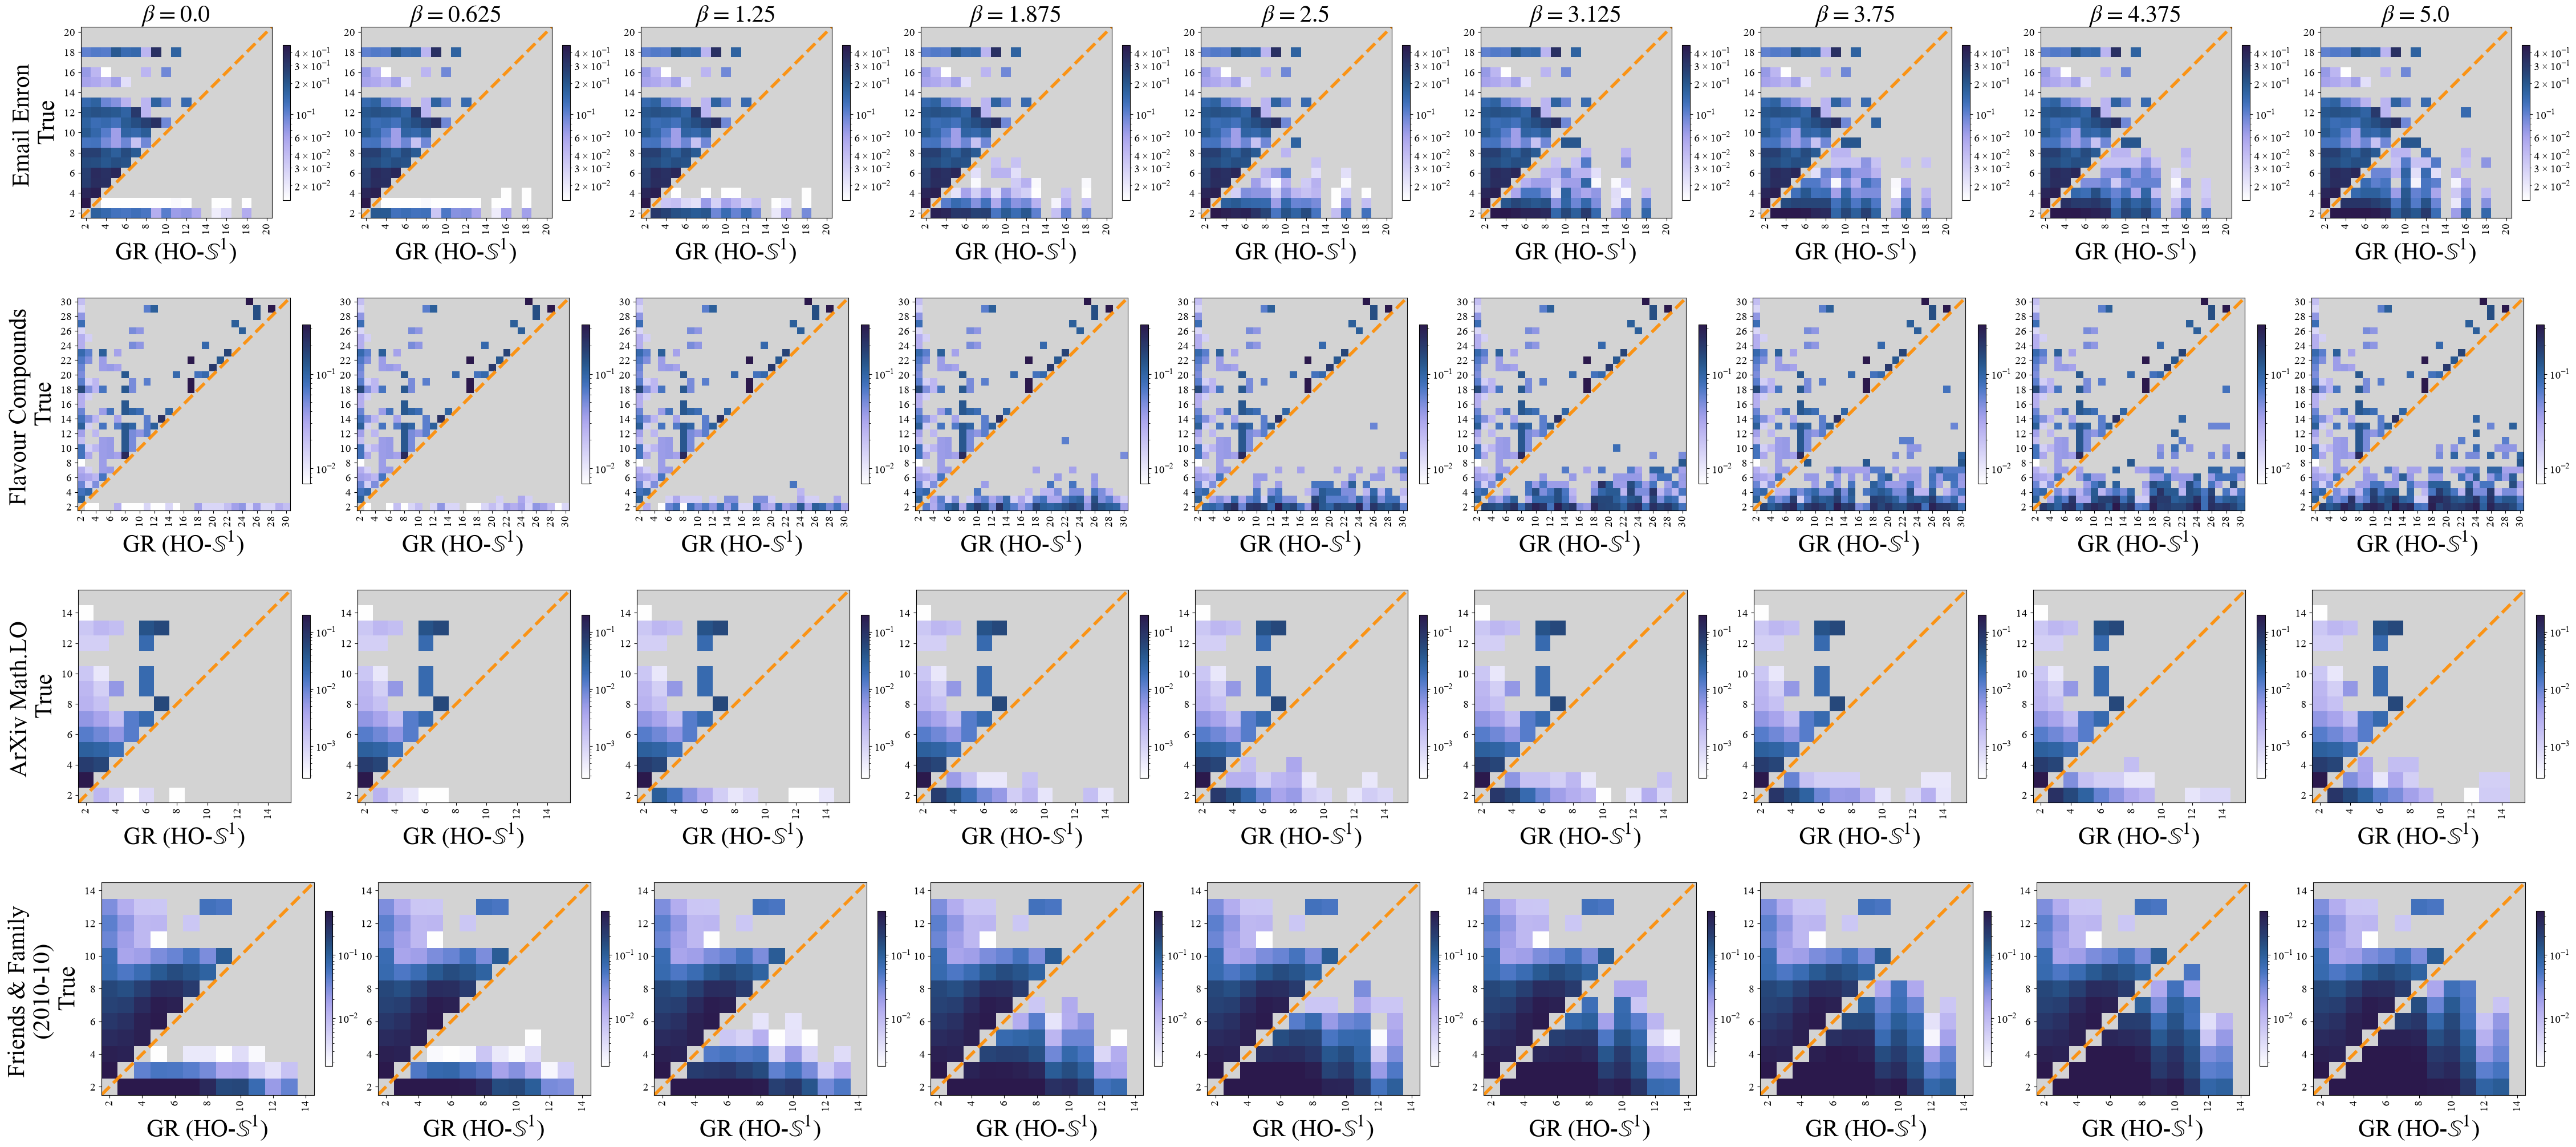

In [32]:
betavalues_to_plot = [ 0.   ,  0.625,  1.25 ,  1.875,  2.5  ,  3.125,  3.75 ,  4.375,   5.   ]
fig = plot_FigS5_SUPP_ALL(DATASETS=MAIN_DATASETS, 
                    MAXLEVELS=MAXLEVELS,
                    DATASET_NAMES=DATASET_NAMES_FORMATTED,
                    SAVE_ROOT=SAVE_ROOT,
                    NREPS={ds: 100 for ds in DATASETS},
                    NROWS = {ds: 1 for ds in DATASETS},
                    beta_vals_to_plot=betavalues_to_plot, 
                    savedata=False
                    )

if savedata:
    fname_out = SAVE_ROOT / "figures" / f"Supp_Fig5.pdf"
    if not fname_out.parent.exists(): fname_out.parent.mkdir(parents=True)
    fig.savefig(fname_out, bbox_inches='tight', dpi=300)
